# Fase 1: Análisis de Casos (Búsqueda vs. Creación)
**Alumno:** Sinuhe Sánchez Contreras  
**Materia:** Inteligencia Artificial  

En esta fase se contrastan las dos metodologías principales para la obtención de activos de datos en ingeniería: la **recolección pasiva** de fuentes secundarias y la **instrumentación activa** para la generación de datos primarios.

---

## Escenario A: Búsqueda e Integración
 **Caso:** Predicción de la demanda eléctrica en Michoacán utilizando datos públicos (CENACE, bases meteorológicas).

### Análisis del Reto
En este escenario, el desafío no es la obtención del dato, sino su curación y alineación. Al trabajar con fuentes externas, nos enfrentamos a la "suciedad" inherente de los datos gubernamentales o climáticos.

* **Data Wrangling:** Transformación de formatos heterogéneos (CSV, JSON, APIs) a un dataframe unificado.
* **Alineación Temporal:** Resolver la inconsistencia de frecuencias (ej. demanda cada hora vs. temperatura cada 15 minutos).
* **Tratamiento de NaN:** Decidir estrategias de imputación para valores nulos sin sesgar la tendencia real de consumo.

---

## Escenario B: Creación e Instrumentación
 **Caso:** Predicción del comportamiento térmico de una estructura metálica específica bajo estrés mecánico y soldadura.

### Análisis del Reto
A diferencia del caso anterior, aquí el ingeniero es el **dueño de la fuente**. El reto se desplaza de la limpieza de software hacia la fidelidad del hardware y la física del entorno.

* **Instrumentación:** Selección crítica de sensores (termopares tipo K) capaces de soportar el rango térmico sin degradarse.
* **Integridad de Señal:** Filtrado del ruido electromagnético (EMI) provocado por el arco eléctrico de la soldadora, el cual puede "ensuciar" las lecturas digitales.
* **Frecuencia de Muestreo:** Determinar la tasa ideal (frecuencia de Nyquist) para capturar transitorios térmicos rápidos sin saturar el almacenamiento.

---

## Comparativa Metodológica

| Característica | Escenario A (Búsqueda) | Escenario B (Creación) |
| :--- | :--- | :--- |
| **Rol del Ingeniero** | Curador y Analista de datos. | Arquitecto de Instrumentación. |
| **Control de Calidad** | Bajo (depende de la entidad pública). | Alto (depende del diseño del circuito). |
| **Esfuerzo Técnico** | SQL, Pandas, Limpieza de archivos. | Hardware, Sensores, Filtrado de Ruido. |
| **Riesgo Principal** | Datos incompletos o desactualizados. | Fallo físico o ruido electromagnético. |

 **Conclusión Crítica:** Mientras que en el Escenario A el éxito depende de nuestra capacidad para unir piezas de un rompecabezas ya existente, en el Escenario B el éxito depende de nuestra capacidad para **fabricar** las piezas del rompecabezas sin errores de medición desde el origen físico.

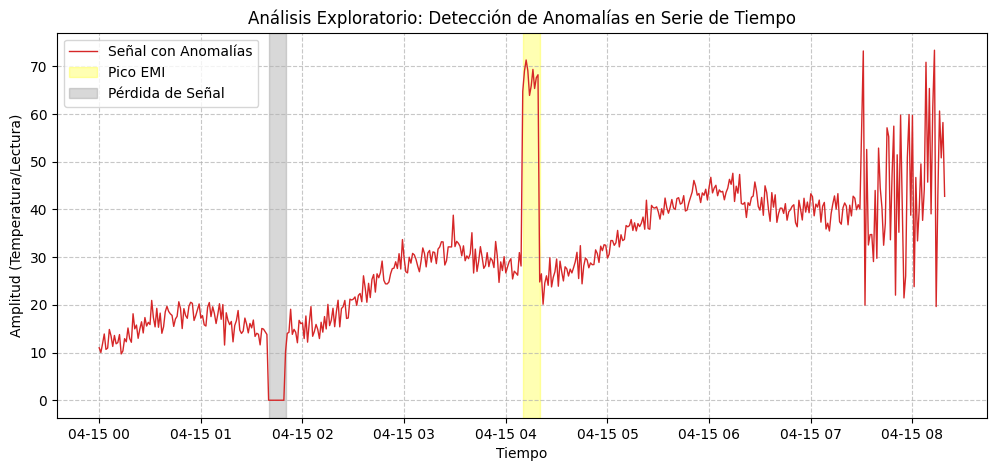

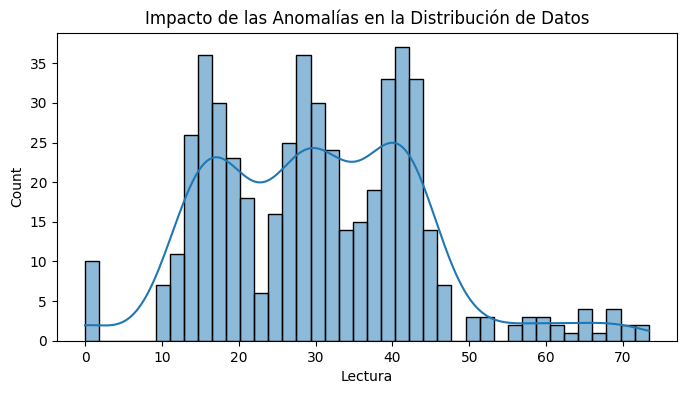

=== Perfil Estadístico con Errores Inyectados ===
          Lectura
count  500.000000
mean    30.298442
std     13.545823
min      0.000000
25%     19.040571
50%     29.719165
75%     40.271333
max     73.367404


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generación de Datos con Anomalías Intencionales
np.random.seed(42)
tiempo = pd.date_range(start='2026-04-15', periods=500, freq='min')

# Señal Base: Tendencia + Oscilación + Ruido
valores = np.linspace(10, 50, 500) + np.sin(np.linspace(0, 20, 500))*5 + np.random.normal(0, 2, 500)

# --- INYECCIÓN DE ANOMALÍAS (El "Sanity Check" debe detectar esto) ---
# Anomalía 1: Pico de interferencia electromagnética (EMI)
valores[250:260] += 40 

# Anomalía 2: Falso contacto o pérdida de señal (caída a cero)
valores[100:110] = 0

# Anomalía 3: Ruido extremo al final (falla de sensor)
valores[450:] += np.random.normal(0, 15, 50)
# ---------------------------------------------------------------------

df = pd.DataFrame({'Timestamp': tiempo, 'Lectura': valores})
df.set_index('Timestamp', inplace=True)

# 2. Inspección Temporal
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Lectura'], label='Señal con Anomalías', color='#d62728', linewidth=1)
plt.axvspan(df.index[250], df.index[260], color='yellow', alpha=0.3, label='Pico EMI')
plt.axvspan(df.index[100], df.index[110], color='gray', alpha=0.3, label='Pérdida de Señal')
plt.title("Análisis Exploratorio: Detección de Anomalías en Serie de Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud (Temperatura/Lectura)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Análisis de Distribución
plt.figure(figsize=(8, 4))
sns.histplot(df['Lectura'], kde=True, bins=40, color='#1f77b4')
plt.title("Impacto de las Anomalías en la Distribución de Datos")
plt.show()

# 4. Estadística Descriptiva
print("=== Perfil Estadístico con Errores Inyectados ===")
print(df.describe())

# Fase 3: Entregable y Conclusiones Críticas
**Alumno:** Sinuhe Sánchez Contreras  
**Materia:** Inteligencia Artificial  

## 1. Análisis de Estacionariedad
**Pregunta:** *Observando la gráfica temporal: ¿La serie de tiempo es estacionaria (su media y varianza son constantes)? ¿Por qué esto es un factor crítico antes de entrenar un modelo predictivo?*

**Análisis:**
La serie de tiempo analizada **no es estacionaria**. 
* **Media no constante:** La implementación de `np.linspace(10, 50)` genera una tendencia ascendente clara; el valor promedio de la señal se desplaza positivamente conforme transcurre el tiempo.
* **Varianza inestable:** Las anomalías inyectadas (picos de voltaje y ruido extremo) provocan que la dispersión de los datos cambie drásticamente en intervalos específicos, rompiendo la homogeneidad de la varianza.

**Importancia Crítica:**
La mayoría de los algoritmos de Machine Learning asumen que las propiedades estadísticas del dataset se mantienen constantes. Si la serie no es estacionaria, el modelo:
1.  Aprenderá una "tendencia" temporal en lugar de la lógica física del fenómeno.
2.  Tendrá un rendimiento pobre al enfrentarse a datos futuros donde la tendencia cambie o se estabilice, resultando en predicciones sesgadas.

---

## 2. Factores Físicos y Outliers (Escenario B)
**Pregunta:** *En el mundo real (Escenario B: soldadura/estrés mecánico), ¿qué factores físicos del entorno podrían generar "picos" atípicos (outliers) en las lecturas?*

En un entorno de instrumentación industrial, las anomalías observadas en nuestro script (`Anomalía 1, 2 y 3`) representarían los siguientes fenómenos:

* **Interferencia Electromagnética (EMI):** Las máquinas de soldar operan con corrientes muy altas que generan campos electromagnéticos masivos. Si el cableado de los sensores no está blindado, el ruido induce picos de voltaje que el sistema registra como temperaturas erróneas.
* **Falsos Contactos por Vibración:** El estrés mecánico puede aflojar momentáneamente las conexiones físicas. Una pérdida de continuidad se refleja como una caída súbita a cero en la lectura del sensor.
* **Degradación Térmica del Sensor:** La exposición continua al calor extremo puede dañar la unión del termopar o el aislamiento del sensor, incrementando el ruido blanco y la incertidumbre en la medición (falla de sensor).

---

## 3. Riesgos de Omitir el Análisis Exploratorio (EDA)
**Pregunta:** *¿Qué riesgos corremos como ingenieros si saltamos esta fase de análisis y conectamos directamente estos datos crudos a una Red Neuronal?*

Saltarse el "Sanity Check" e ir directo al entrenamiento con Keras o PyTorch conlleva riesgos técnicos severos:

1.  **Garbage In, Garbage Out (Basura entra, basura sale):** La red neuronal intentará encontrar patrones matemáticos en el ruido y las interferencias, asumiendo que son parte del proceso físico, lo que invalida el modelo.
2.  **Gradientes Explosivos:** Los *outliers* extremos pueden generar errores masivos durante el entrenamiento (backpropagation), causando que los pesos de la red se desestabilicen y el modelo no logre converger (errores tipo `NaN`).
3.  **Sobreajuste (Overfitting) al Ruido:** La red desperdiciará neuronas y capacidad de cómputo memorizando las fallas del sensor en lugar de aprender el comportamiento térmico real de la estructura metálica.

---

**Conclusión del Perfil Estadístico:**
Como muestra el método `df.describe()`, la desviación estándar y los valores máximos están distorsionados por las anomalías. Antes de cualquier modelado, es imperativo aplicar técnicas de **limpieza de datos (Data Wrangling)** y filtrado de señales.